# COVID-19 Data Cleaning Notebook

---

## Step 1: Load dataset
We load the raw COVID-19 dataset from your Downloads folder using pandas.  
This allows us to work with the data in Python.

In [1]:
import pandas as pd
import os

#Load dataset
df = pd.read_csv(r"c:\Users\USER\Downloads\COVID_19 FULL DATA SET.csv") 

## Step 2: Inspect dataset
We inspect the first few rows to understand the data structure and check for missing values.

In [2]:
#Inspect dataset
print(df.head())
print(df.isnull().sum())

       country      date  total_cases  new_cases  new_cases_smoothed  \
0  Afghanistan  1/1/2020          NaN        NaN                 NaN   
1  Afghanistan  1/2/2020          NaN        NaN                 NaN   
2  Afghanistan  1/3/2020          NaN        NaN                 NaN   
3  Afghanistan  1/4/2020          0.0        0.0                 NaN   
4  Afghanistan  1/5/2020          0.0        0.0                 NaN   

   total_cases_per_million  new_cases_per_million  \
0                      NaN                    NaN   
1                      NaN                    NaN   
2                      NaN                    NaN   
3                      0.0                    0.0   
4                      0.0                    0.0   

   new_cases_smoothed_per_million  total_deaths  new_deaths  ...  population  \
0                             NaN           NaN         NaN  ...  40578847.0   
1                             NaN           NaN         NaN  ...  40578847.0   
2       

## Step 3: Cleaning
We clean the dataset by:  
1. Replacing missing values with 0  
2. Removing duplicate rows  
3. Converting the `date` column to datetime format for proper date handling

In [3]:
#Cleaning
df = df.fillna(0)           # Replace missing values
df = df.drop_duplicates()    # Drop duplicates
df["date"] = pd.to_datetime(df["date"])  # Convert date

## Step 4: Save in /data folder
We save the cleaned dataset into a `data` folder in the current project directory.  
If the folder does not exist, it will be created automatically.

In [4]:
#Save in /data folder
data_folder = os.path.join(os.getcwd(), "data")
os.makedirs(data_folder, exist_ok=True)
clean_file = os.path.join(data_folder, "clean_covid_data.csv")
df.to_csv(clean_file, index=False)

print("Clean dataset saved in:", clean_file)

Clean dataset saved in: c:\Users\USER\Downloads\covid-data-cleaning\data\clean_covid_data.csv


### Total COVID-19 Cases by Country

We group the data by country and take the maximum number of total cases, since the values are cumulative over time.

In [12]:
import pandas as pd

df = pd.read_csv(r"c:\Users\USER\Downloads\covid-data-cleaning\Data\clean_covid_data.csv")
cases_by_country = df.groupby("country")["total_cases"].max()
print(cases_by_country.head())

country
Afghanistan         235214.0
Africa            13063807.0
Albania             337234.0
Algeria             272435.0
American Samoa        8359.0
Name: total_cases, dtype: float64


### Total COVID-19 Deaths by Country

We calculate the total number of deaths per country using the maximum values.

In [14]:
deaths_by_country = df.groupby("country")["total_deaths"].max()
print(deaths_by_country.head())

country
Afghanistan         7998.0
Africa            258288.0
Albania             3608.0
Algeria             6881.0
American Samoa        34.0
Name: total_deaths, dtype: float64


### Average New Cases per Country

We compute the average number of new cases per country to understand general infection trends.

In [15]:
avg_new_cases = df.groupby("country")["new_cases"].mean()
print(avg_new_cases.head())

country
Afghanistan        104.772383
Africa            5827.593220
Albania            150.215590
Algeria            121.351893
American Samoa       3.728368
Name: new_cases, dtype: float64


### Global COVID-19 Cases Over Time

We group the data by date and sum the new cases to observe the global trend over time.

In [17]:
cases_by_date = df.groupby("date")["new_cases"].sum()
print(cases_by_date.head())

date
2020-01-01     0.0
2020-01-02     0.0
2020-01-03     0.0
2020-01-04    20.0
2020-01-05     0.0
Name: new_cases, dtype: float64


### Summary Statistics by Country

We compute multiple statistics per country, including total cases, total deaths, and average new cases.

In [18]:
summary = df.groupby("country").agg({
    "total_cases": "max",
    "total_deaths": "max",
    "new_cases": "mean"
})

print(summary.head())

                total_cases  total_deaths    new_cases
country                                               
Afghanistan        235214.0        7998.0   104.772383
Africa           13063807.0      258288.0  5827.593220
Albania            337234.0        3608.0   150.215590
Algeria            272435.0        6881.0   121.351893
American Samoa       8359.0          34.0     3.728368


In [19]:
import matplotlib.pyplot as plt
import seaborn as sns

# Optionnel : style sympa
sns.set(style="whitegrid")

### Bar Chart: Total Cases per Country
We plot the total COVID-19 cases per country to see which countries are most affected.

C:\Users\USER\AppData\Local\Temp\ipykernel_16160\595208489.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top10_cases.index, y=top10_cases.values, palette="Reds_r")


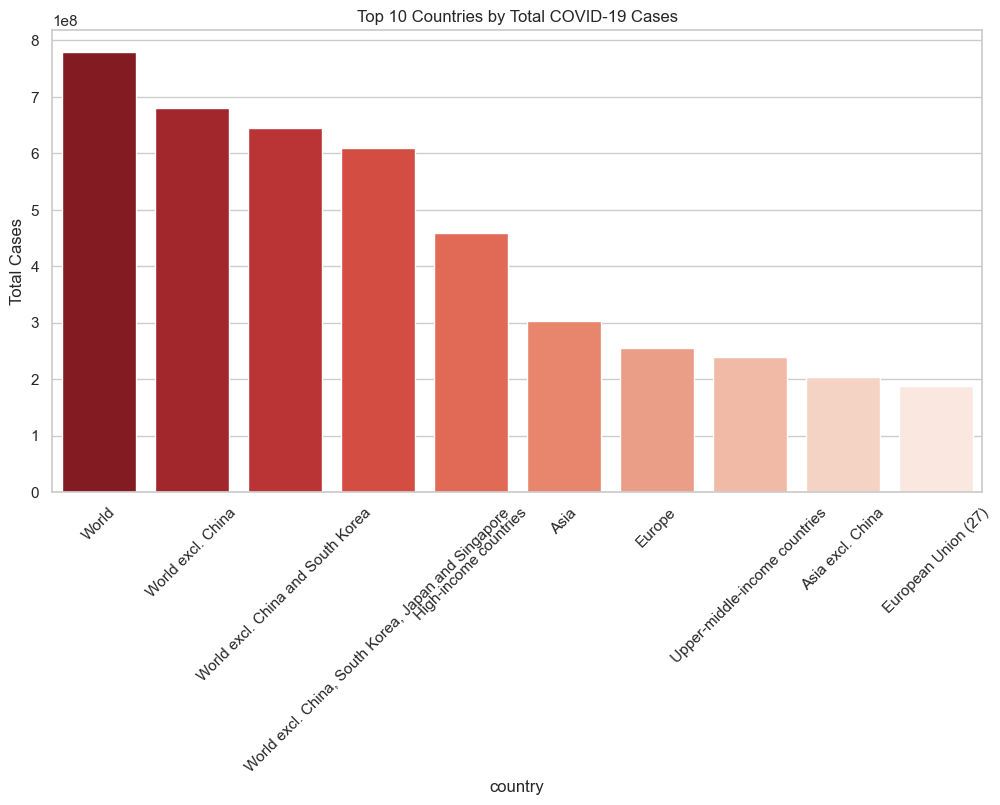

In [20]:
# we take the top 10 countries most affected 
top10_cases = df.groupby("country")["total_cases"].max().sort_values(ascending=False).head(10)

plt.figure(figsize=(12,6))
sns.barplot(x=top10_cases.index, y=top10_cases.values, palette="Reds_r")
plt.xticks(rotation=45)
plt.ylabel("Total Cases")
plt.title("Top 10 Countries by Total COVID-19 Cases")
plt.show()

**Interpretation:**  
This bar chart shows the top 10 countries with the highest total COVID-19 cases.  
We can see that some countries have been heavily affected, with case counts far higher than others.  
This helps identify which countries faced the most severe outbreaks.

### Line Chart: Global New Cases Over Time
We sum the new cases per date to see the global trend.

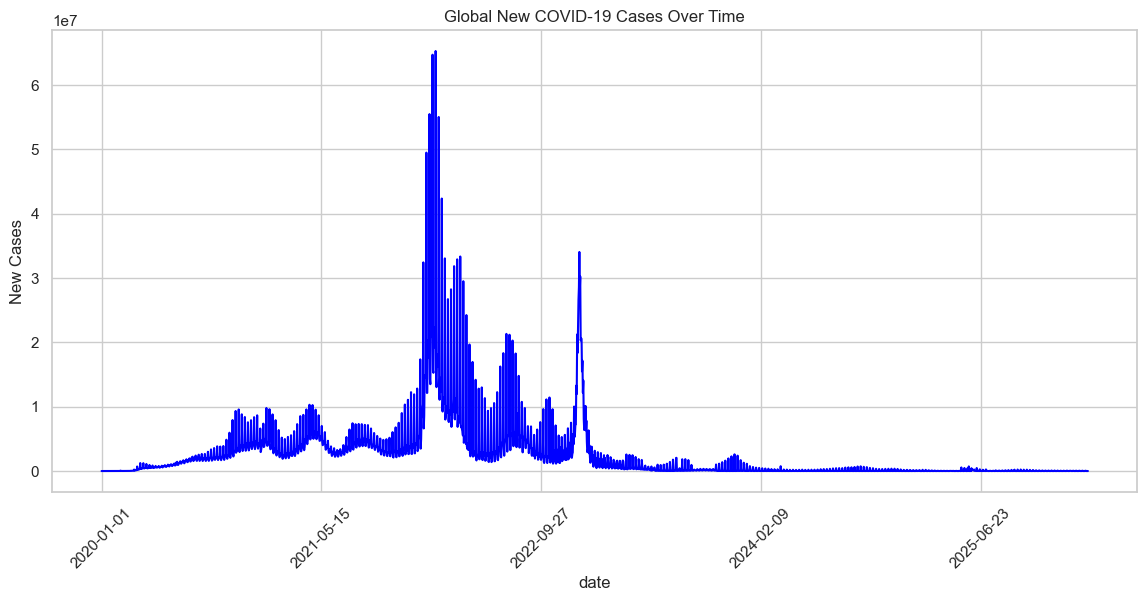

In [21]:
cases_by_date = df.groupby("date")["new_cases"].sum()

plt.figure(figsize=(14,6))
cases_by_date.plot(kind="line", color="blue")
plt.xticks(rotation=45)
plt.ylabel("New Cases")
plt.title("Global New COVID-19 Cases Over Time")
plt.show()

**Interpretation:**  
The line chart shows the global trend of daily new COVID-19 cases over time.  
We can observe peaks that indicate waves of infections and periods of slower spread.  
This visualization highlights the overall progression of the pandemic worldwide.

### Distribution Plot: New Cases
We visualize the distribution of daily new cases to see how they spread.

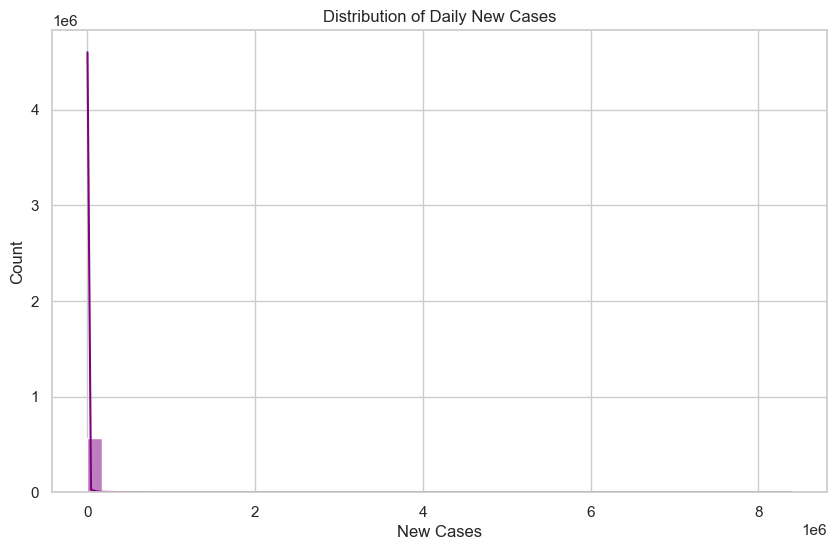

In [22]:
plt.figure(figsize=(10,6))
sns.histplot(df["new_cases"].dropna(), bins=50, kde=True, color="purple")
plt.xlabel("New Cases")
plt.title("Distribution of Daily New Cases")
plt.show()

**Interpretation:**  
The distribution plot shows how daily new cases are spread across all countries and dates.  
Most days have relatively low new case counts, but there are a few days with very high numbers, indicating extreme spikes.  
This shows that the data is right-skewed with occasional large outbreaks.

### Comparative Plot: Total Deaths vs Total Cases
We compare total deaths to total cases by country for the top 10 countries.

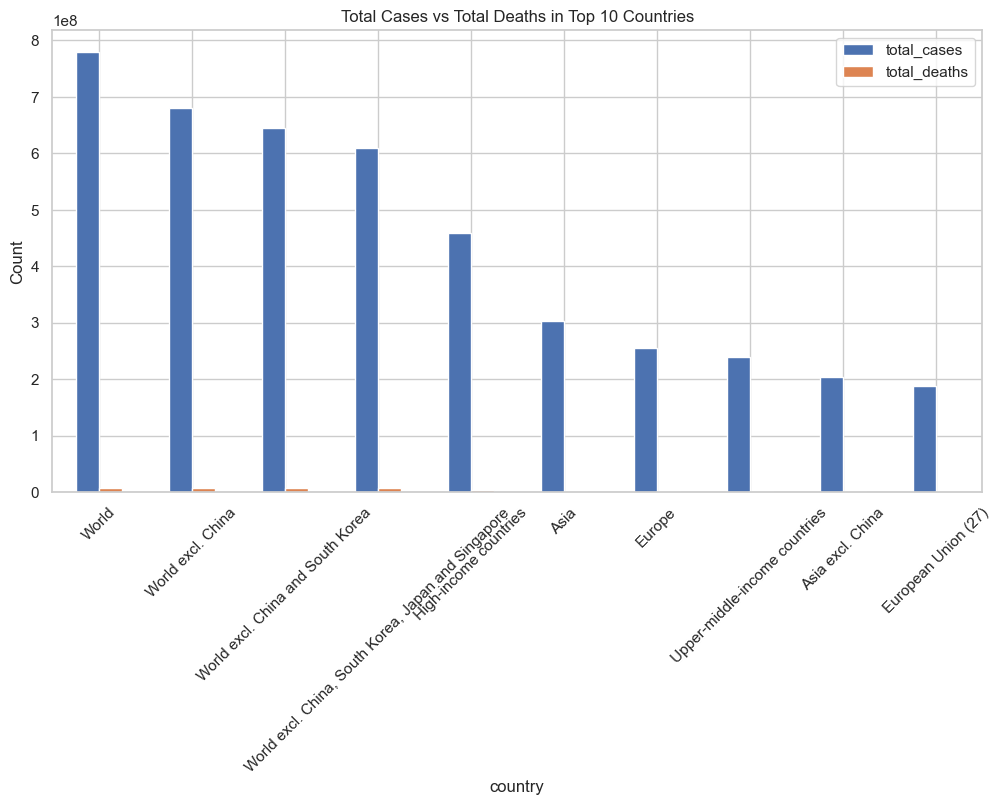

In [23]:
top10 = df.groupby("country")[["total_cases", "total_deaths"]].max().sort_values("total_cases", ascending=False).head(10)

top10.plot(kind="bar", figsize=(12,6))
plt.ylabel("Count")
plt.title("Total Cases vs Total Deaths in Top 10 Countries")
plt.xticks(rotation=45)
plt.show()

**Interpretation:**  
This bar chart compares total deaths and total cases for the top 10 countries.  
We can see that while some countries have high case numbers, their death counts may be lower relative to others.  
It helps us understand the severity of outbreaks in different countries.

### Boxplot: New Cases per Country
We check how the daily new cases vary across countries.

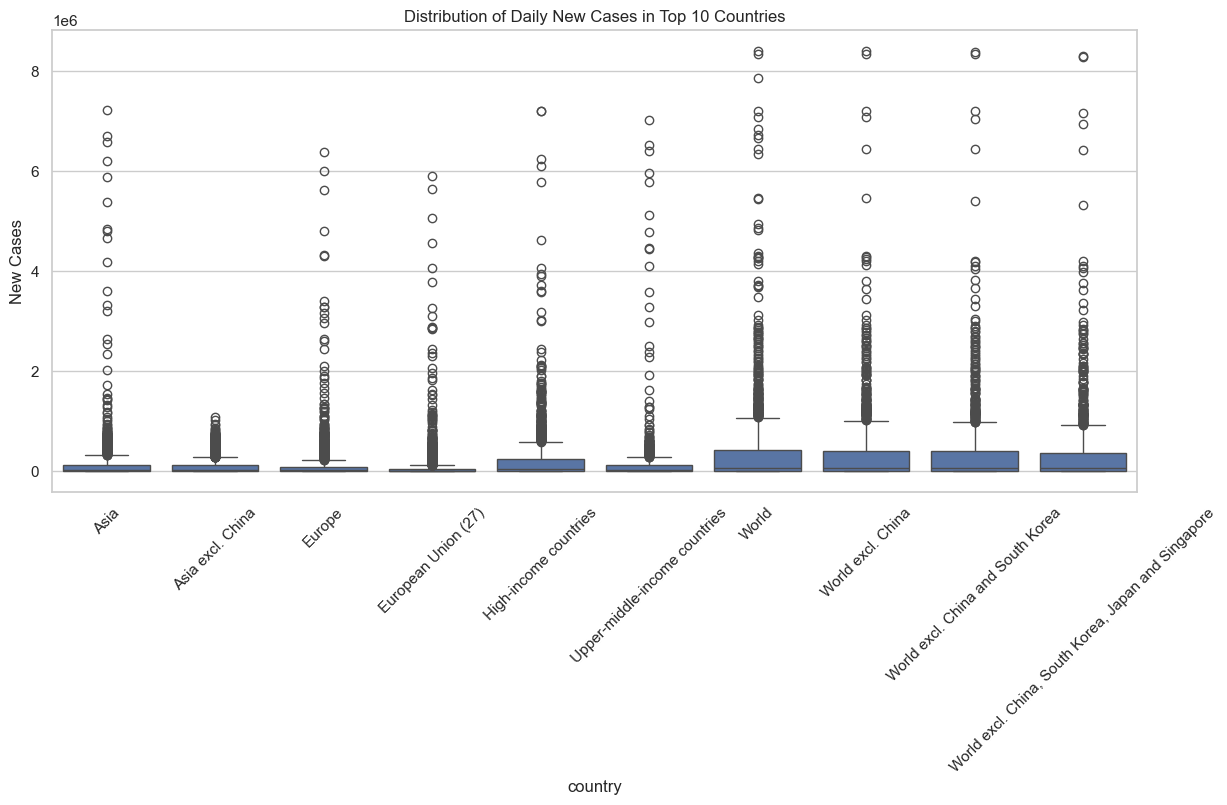

In [24]:
plt.figure(figsize=(14,6))
sns.boxplot(x="country", y="new_cases", data=df[df["country"].isin(top10_cases.index)])
plt.xticks(rotation=45)
plt.ylabel("New Cases")
plt.title("Distribution of Daily New Cases in Top 10 Countries")
plt.show()

**Interpretation:**  
The boxplot shows the distribution of daily new cases for the top 10 countries.  
We can see variation in daily case counts, outliers representing spikes, and the general range for each country.  
This visualization highlights differences in pandemic intensity and volatility among countries.